In [1]:
import re
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
)
from sklearn.feature_selection import chi2

import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42


In [2]:
DATA_PATH = "final_combined_enriched_v4.csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Put the CSV next to this notebook, or set DATA_PATH to the full path."
    ) from e

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())


Shape: (50169, 2)


,tweet,type
0,This cartoon by Alok @caricatured speak about the reality of deals in Indian Politics - Backdoor - or Unholy nexus ...,1
1,I am going to post one #BernieAtTheFarmersProtest every day until either the Farmers protest ends or @BernieSanders ...,1
2,@sardesairajdeep @OfficialUrmila @RahulGandhi So bashing Islamic terrorism is communal but when someone talks about ...,1
3,Oooh... that`s right by the zoo... think... in 2 months` time that could be our regular other meeting place,0
4,@vivekoberoi @narendramodi @OmungKumar @sureshoberoi @sandip_Ssingh @TSeries @anandpandit63 Absolutely very nice and...,1



Columns: ['tweet', 'type']


In [3]:
# --- Detect text column ---
TEXT_CANDIDATES = ["tweet", "text", "content", "clean_tweet", "raw_tweet"]
LABEL_CANDIDATES = ["type", "label", "is_political", "political"]

text_col = next((c for c in TEXT_CANDIDATES if c in df.columns), None)
label_col = next((c for c in LABEL_CANDIDATES if c in df.columns), None)

if text_col is None or label_col is None:
    raise ValueError(
        f"Couldn't find expected columns. Found: {df.columns.tolist()}\n"
        f"Expected one of text: {TEXT_CANDIDATES} and label: {LABEL_CANDIDATES}"
    )

df = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"})

# Drop missing + duplicates
df = df.dropna(subset=["text", "label"]).drop_duplicates(subset=["text"]).copy()
df["text"] = df["text"].astype(str)

if df["label"].dtype == "O":
    normalized = df["label"].astype(str).str.strip().str.lower()
    mapping = {
        "political": 1,
        "non-political": 0,
        "nonpolitical": 0,
        "not political": 0,
        "0": 0,
        "1": 1,
        "true": 1,
        "false": 0,
    }
    df["label"] = normalized.map(mapping)
    # If still missing, try to coerce numeric:
    if df["label"].isna().any():
        df["label"] = pd.to_numeric(normalized, errors="coerce")

df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

print("After cleaning:", df.shape)
print(df["label"].value_counts().rename({0: "non-political(0)", 1: "political(1)"}))
display(df.sample(5, random_state=RANDOM_STATE))


After cleaning: (50034, 2)
label
political(1)        27324
non-political(0)    22710
Name: count, dtype: int64


,text,label
30366,"@UjwalLatkar @pbhushan1 @mkatju 1) There has been only 2 PMs in India post 1967 , who were / are adept in taking dec...",1
46297,I am loving this beautiful monday morning!,0
44793,"That`s a great point... but I`m not **** in ANY! woods, Sara... you should know better. Haha",0
15621,"@RahulGandhi says Was it Not BJP That Sent Masood Azhar Back to Pakistan? \nYes, it was BJP, because of situation an...",1
7783,When UK is turning Indian in Politics... such things are the norm.,1


,count,percent
label,,
non-political,22710,45.39
political,27324,54.61


,count,mean,std,min,25%,50%,75%,max
n_chars,50034.0,163.914178,94.105409,3.0,84.0,152.0,250.0,995.0
n_words,50034.0,24.089439,13.477370,1.0,13.0,22.0,35.0,102.0


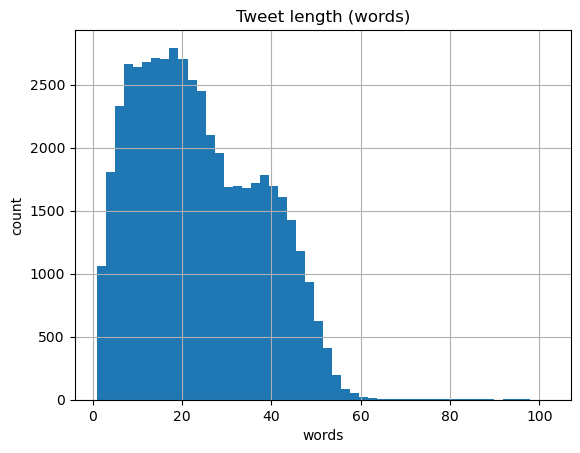


Examples (political=1):


,text
47000,@RahulGandhi True we support #rahulgandhi @RahulGandhi #narendramodichorhai #bjpkesbhinetachorhai
29835,"#CongressManifesto - Mr. @RahulGandhi \nYou forgot to add in your document, how all of India's awards, monuments, ai..."
27110,@ANI You are a third rate fellow Rahul and you stoop to any any low level. You dont know your religion and is not pr...



Examples (non-political=0):


,text
40869,पंजाब पुलिस (#PunjabPolice) और महाराष्ट्र पुलिस के संयुक्त अभियान में शुक्रवार को #मुंबई के न्हावा शेवा पोर्ट पर एक ...
5588,just woke up...for once I managed to sleep in!! going out for lunch later then back to essay
25938,"Had a great night, ashleigh makes a good dance teacher And we kicked Bens butt at a pillow fight!"


In [4]:
# Class balance
counts = df["label"].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)
eda = pd.DataFrame({"count": counts, "percent": pct}).rename(index={0: "non-political", 1: "political"})
display(eda)

# Tweet length distribution
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().map(len)

display(df[["n_chars", "n_words"]].describe().T)

plt.figure()
df["n_words"].hist(bins=50)
plt.title("Tweet length (words)")
plt.xlabel("words")
plt.ylabel("count")
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

# Quick peek at some examples
print("\nExamples (political=1):")
display(df[df["label"] == 1].sample(3, random_state=RANDOM_STATE)[["text"]])

print("\nExamples (non-political=0):")
display(df[df["label"] == 0].sample(3, random_state=RANDOM_STATE)[["text"]])


In [5]:
URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_tweet(text: str) -> str:
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    # keep hashtag word, drop '#'
    text = HASHTAG_RE.sub(r"\1", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

# quick demo
demo = df["text"].head(5).tolist()
for t in demo:
    print("RAW:  ", t)
    print("CLEAN:", clean_tweet(t))
    print("---")


RAW:   This cartoon by Alok @caricatured  speak about the reality of deals in Indian Politics - Backdoor - or Unholy nexus - when all guys unite on controlling money minting Cricket Administration 😎
CLEAN: this cartoon by alok speak about the reality of deals in indian politics - backdoor - or unholy nexus - when all guys unite on controlling money minting cricket administration 😎
---
RAW:   I am going to post one #BernieAtTheFarmersProtest every day until either the Farmers protest ends or @BernieSanders @SenSanders notices this and highlights the issue. Or I get blocked by Twitter. #Berniememes #BernieSandersMittens #BernieSanders #FarmersProtest 34 https://t.co/2NFSWxE6fA
CLEAN: i am going to post one bernieatthefarmersprotest every day until either the farmers protest ends or notices this and highlights the issue. or i get blocked by twitter. berniememes berniesandersmittens berniesanders farmersprotest 34
---
RAW:   @sardesairajdeep @OfficialUrmila @RahulGandhi So bashing Islamic 

In [6]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test balance: ", y_test.value_counts(normalize=True).round(3).to_dict())


Train size: 40027  Test size: 10007
Train balance: {1: 0.546, 0: 0.454}
Test balance:  {1: 0.546, 0: 0.454}


In [7]:
dummy = Pipeline([
    ("tfidf", TfidfVectorizer(preprocessor=clean_tweet, stop_words="english")),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])

dummy.fit(X_train, y_train)
pred = dummy.predict(X_test)

print("Dummy baseline (most_frequent)\n")
print(classification_report(y_test, pred, digits=3))


Dummy baseline (most_frequent)

              precision    recall  f1-score   support

           0      0.000     0.000     0.000      4542
           1      0.546     1.000     0.706      5465

    accuracy                          0.546     10007
   macro avg      0.273     0.500     0.353     10007
weighted avg      0.298     0.546     0.386     10007



C:\Users\chezk\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\chezk\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\chezk\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=clean_tweet,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2
    )),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=clean_tweet,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2
    )),
    ("clf", MultinomialNB(alpha=1.0)),
])

svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=clean_tweet,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2
    )),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
])

models = {"LogReg": lr, "MultinomialNB": nb, "LinearSVC": svm}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred, digits=3))



=== LogReg ===
              precision    recall  f1-score   support

           0      0.962     0.990     0.976      4542
           1      0.992     0.967     0.979      5465

    accuracy                          0.978     10007
   macro avg      0.977     0.979     0.977     10007
weighted avg      0.978     0.978     0.978     10007


=== MultinomialNB ===
              precision    recall  f1-score   support

           0      0.961     0.879     0.918      4542
           1      0.906     0.970     0.937      5465

    accuracy                          0.929     10007
   macro avg      0.934     0.925     0.928     10007
weighted avg      0.931     0.929     0.929     10007


=== LinearSVC ===
              precision    recall  f1-score   support

           0      0.976     0.990     0.983      4542
           1      0.992     0.980     0.986      5465

    accuracy                          0.984     10007
   macro avg      0.984     0.985     0.984     10007
weighted avg    

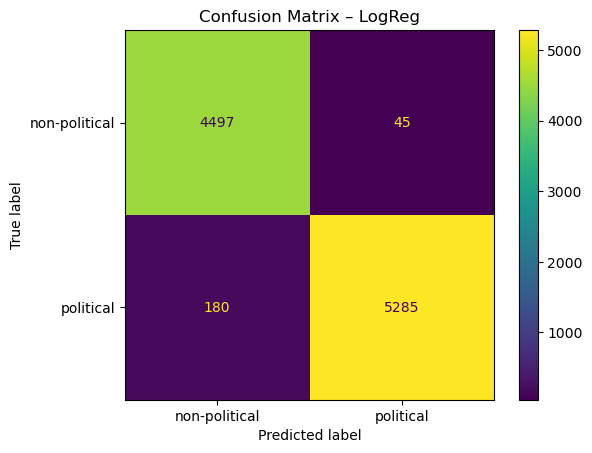

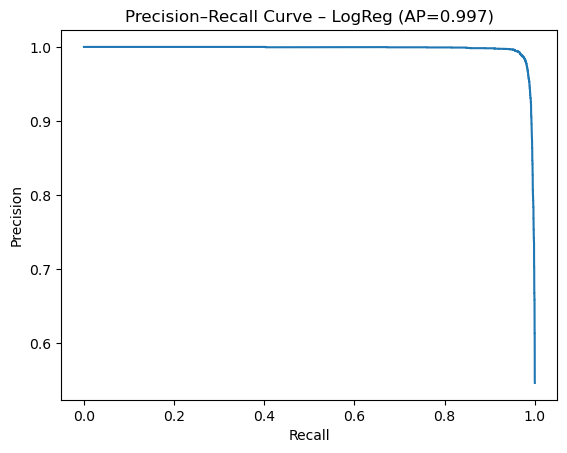

Average precision (PR-AUC): 0.9971
ROC-AUC: 0.9958


In [9]:
best_name = "LogReg"
best_model = models[best_name]

# Confusion matrix
pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-political", "political"])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix – {best_name}")
plt.savefig("figure2.png", dpi=300, bbox_inches="tight")
plt.show()

# PR curve needs probabilities
proba = best_model.predict_proba(X_test)[:, 1]
ap = average_precision_score(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)

plt.figure()
plt.plot(rec, prec)
plt.title(f"Precision–Recall Curve – {best_name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.savefig("figure3.png", dpi=300, bbox_inches="tight")
plt.show()


roc = roc_auc_score(y_test, proba)
print(f"Average precision (PR-AUC): {ap:.4f}")
print(f"ROC-AUC: {roc:.4f}")


In [10]:

# Choose a decision threshold that maximizes F1 on the test split 
proba = best_model.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, proba)

# thresholds has length = len(prec)-1; align arrays
f1s = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_idx = int(np.argmax(f1s))
best_thresh = float(thresholds[best_idx])

y_pred_thresh = (proba >= best_thresh).astype(int)

print(f"Best threshold (max F1): {best_thresh:.3f}")
print(f"F1 at best threshold: {f1s[best_idx]:.3f}\n")
print(classification_report(y_test, y_pred_thresh, digits=3))


Best threshold (max F1): 0.376
F1 at best threshold: 0.981

              precision    recall  f1-score   support

           0      0.974     0.980     0.977      4542
           1      0.983     0.978     0.981      5465

    accuracy                          0.979     10007
   macro avg      0.979     0.979     0.979     10007
weighted avg      0.979     0.979     0.979     10007



In [11]:

y_pred_default = best_model.predict(X_test)

error_df = pd.DataFrame({
    "text": X_test.values,
    "y_true": y_test.values,
    "y_pred": y_pred_default
})

false_neg = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]
false_pos = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]

print("False negatives (political → predicted non-political):", len(false_neg))
display(false_neg.sample(min(10, len(false_neg)), random_state=RANDOM_STATE)[["text"]])

print("\nFalse positives (non-political → predicted political):", len(false_pos))
display(false_pos.sample(min(10, len(false_pos)), random_state=RANDOM_STATE)[["text"]])


False negatives (political → predicted non-political): 180


,text
1250,विश्व युवा कौशल दिवस पर देश की युवा शक्ति को उनके उज्जवल भविष्य एवं संकल्प सिद्धि की हार्दिक शुभकामनाएं। #India #BJ...
2476,"First I2U2 projects to promote agriculture, food, green energy in India https://t.co/JpkEU7m3d0 @narendramodi #I..."
8451,"After reaching a high of 7.79% in April 2022, consumer price index dipped to a low of 7.01% in June 2022. Despite t..."
4868,#SushmitaSen ⁦@thesushmitasen⁩ dating Lalit Modi? #IPL founder shares cozy PICS with actress from #Maldives vacation...
7924,"@yash25more No, No, No. You do not understand. Modi said no exports but did not say no imports. So, money is all goi..."
1057,திரெளபதி மர்முவுக்கு ஜார்க்கண்ட் முக்தி மோர்ச்சா ஆதரவு...! #India #PresidentialElection #DraupadiMurmu #Kumudam h...
1549,Trending in my timeline now: #NaMoApp (12) #India (3) #PMModi (3) #LizTruss (3) #IEA (3) #Lunch (2) #NewZeala...
3862,GOOD STUFF! 👉@Geeta_Mohan live-tweets latest DOW DUPONT BURN PIT BIDEN painful adventure. Israel's current head of g...
6551,@MSDESkillIndia @dpradhanbjp @Rajeev_GoI @PIB_India @PMOIndia @airnewsalerts @NSDCINDIA #India is taking a step forw...
6635,$FB $SNAP $AMZN $GOOGL are a bargain The #India #advertising market is forecast to grow by 16 per cent in 2022 to r...



False positives (non-political → predicted political): 45


,text
9068,@mieknathshinde @Dev_Fadnavis mahadev bholenath ne teesri aankh khol li h ab insaaf chye disha salian or Sushant ...
5528,"#Today #prestige #Delhi Are Western #prizes like #NobelPrize spoiling the rest? With #Gandhi not making it, its the ..."
5766,People of kashmir are feeling #blessed to be a part of such a great nation #India which is turning J&amp;K into a wo...
9901,Feeling really good about my performance on the AP Government & Politics exam this morning. Going to lunch with Kri...
7982,Chai Wala (Tea seller) PM and Rickshaw Wala (Rickshaw driver) CM. How is democracy in danger? A new India... For eve...
9511,Am really worried for our whole nation What the freak is goin on!! You can't change our national emblem That stands...
1777,"Arfa Ji has Good obsession with Kaum,Identity/Nishaniya,Ummat,Moral support for bike thieves belonging to a particul..."
2575,Our upcoming #webinar on “ How to resolve #business #contractdisputes in #India” highlights the key issues in managi...
1961,@anandmahindra Sir request you to pls pls RT this.let this go beyond the expectations&amp; help the poor animals #Sa...
1664,there are many factors contributing towards this “brain drain” issue in india. most important &amp; the most commonl...


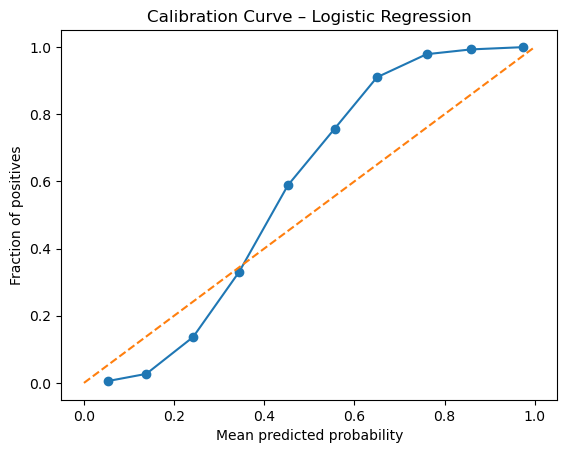

In [12]:

proba = best_model.predict_proba(X_test)[:, 1]
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")

plt.figure()
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve – Logistic Regression")
plt.show()


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid_lr = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "clf__C": [0.5, 1.0, 2.0],
}

gs_lr = GridSearchCV(
    lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_)
print("Best CV f1:", gs_lr.best_score_)

tuned_lr = gs_lr.best_estimator_
pred = tuned_lr.predict(X_test)
print("\nTuned Logistic Regression (test set)\n")
print(classification_report(y_test, pred, digits=3))


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best LR params: {'clf__C': 2.0, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV f1: 0.9805304900254621

Tuned Logistic Regression (test set)

              precision    recall  f1-score   support

           0      0.967     0.991     0.979      4542
           1      0.993     0.972     0.982      5465

    accuracy                          0.981     10007
   macro avg      0.980     0.981     0.980     10007
weighted avg      0.981     0.981     0.981     10007



In [14]:
# Fit a vectorizer on the full training set to inspect features
vec = TfidfVectorizer(
    preprocessor=clean_tweet,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2
)
X_train_vec = vec.fit_transform(X_train)
feature_names = np.array(vec.get_feature_names_out())

chi2_scores, pvals = chi2(X_train_vec, y_train)
top_pos = np.argsort(chi2_scores)[-25:][::-1]

print("Top 25 features most associated with the label (chi2):\n")
for idx in top_pos:
    print(f"{feature_names[idx]:<30} chi2={chi2_scores[idx]:.2f}")

# If you want per-class directionality, look at mean tf-idf by class:
X0 = X_train_vec[y_train.values == 0].mean(axis=0).A1
X1 = X_train_vec[y_train.values == 1].mean(axis=0).A1
diff = X1 - X0
top_pol = np.argsort(diff)[-20:][::-1]
top_non = np.argsort(diff)[:20]

print("\nTop features with higher avg TF-IDF in political tweets:")
print(feature_names[top_pol])

print("\nTop features with higher avg TF-IDF in non-political tweets:")
print(feature_names[top_non])


Top 25 features most associated with the label (chi2):

politics                       chi2=452.16
loksabhaelections2019          chi2=438.22
bjp                            chi2=425.01
rahulgandhi                    chi2=399.06
indian                         chi2=386.93
modi                           chi2=313.71
indian politics                chi2=303.57
congress                       chi2=296.66
gandhi                         chi2=270.39
rahul                          chi2=252.35
pm                             chi2=200.57
farmersprotest                 chi2=190.33
narendramodi                   chi2=179.94
rahul gandhi                   chi2=166.96
ji                             chi2=149.77
amp                            chi2=143.61
vote                           chi2=127.31
india                          chi2=125.01
im                             chi2=112.61
lol                            chi2=110.78
election                       chi2=106.33
day                            chi2=106.2

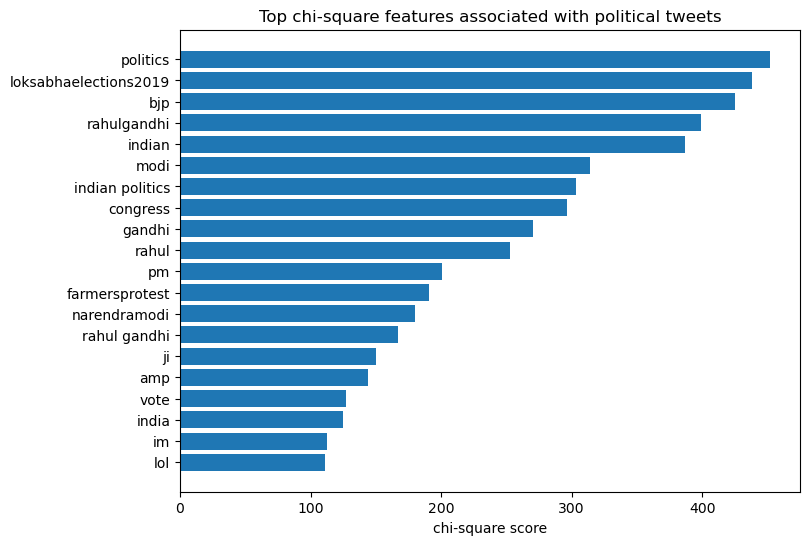

In [15]:
# Plot top chi-square features for quick interpretation (saved for the white paper)
top_k = 20
top_idx = np.argsort(chi2_scores)[-top_k:][::-1]
top_terms = feature_names[top_idx]
top_scores = chi2_scores[top_idx]

plt.figure(figsize=(8, 6))
plt.barh(range(top_k)[::-1], top_scores)  # reversed so highest is at top
plt.yticks(range(top_k)[::-1], top_terms)
plt.xlabel("chi-square score")
plt.title("Top chi-square features associated with political tweets")
plt.savefig("figure4.png", dpi=300, bbox_inches="tight")
plt.show()